Connected to hyriver-dev (Python 3.12.5)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from pathlib import Path
from tqdm import tqdm # Great for progress bars on big datasets

# --- Setup ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"
state_code = "OR"  # Ensure this matches your previous runs
YEARS = np.arange(1920, 2025, 5)

print("1) Loading Datasets...")
master_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_Master_Spatiotemporal_Matrix.parquet")
led_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_LED_Joined_Buildings.parquet")

# Make sure HISDAC_id is the index of master_df for instant lookups
master_idx = master_df.set_index('HISDAC_id')

def generate_probability_array(row):
    """Generates the 21-element array for a single building."""
    hid = row['HISDAC_id']
    
    # If the building is in a location where HISDAC completely failed to create a pixel
    if hid not in master_idx.index:
        prob_array = np.zeros(21)
        year_idx = np.where(YEARS == row['semi_decade'])[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    pixel = master_idx.loc[hid]
    
    # Extract variables
    led_year = row['semi_decade']
    source_nsi = row.get('source_nsi', 'unknown')
    stories = row.get('num_story', 1)
    if pd.isna(stories): stories = 1
    
    # Extract arrays
    hisdac_bupl = np.array([pixel[f'D_BUPL{y}'] for y in YEARS])
    led_counts = np.array([pixel[f'LED_{y}'] for y in YEARS])
    density = pixel['DENSITY']
    fbuy = pixel['FBUY']
    
    prob_array = np.zeros(21)
    
    # TIER 1: HISDAC Void
    if pd.isna(fbuy) or np.sum(hisdac_bupl) == 0:
        year_idx = np.where(YEARS == led_year)[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    # TIER 4: Urban Blender (Density > 3.0)
    if density > 3.0:
        if stories > 3:
            # The Culprit
            hisdac_bupr = np.array([pixel[f'D_BUPR{y}'] for y in YEARS])
            if np.sum(hisdac_bupr) > 0:
                return hisdac_bupr / np.sum(hisdac_bupr)
            return np.ones(21) / 21
        else:
            # The Bystander
            base_dist = hisdac_bupl / np.sum(hisdac_bupl)
            gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=10)
            prob_array = base_dist * gaussian_weights
            return prob_array / np.sum(prob_array) if np.sum(prob_array) > 0 else base_dist

    # TIER 3: Deficit Allocation (nsi_estimated)
    if source_nsi == 'nsi_estimated':
        recent_idx = slice(16, 21) # 2000-2020
        deficits = np.maximum(0, hisdac_bupl[recent_idx] - led_counts[recent_idx])
        if np.sum(deficits) > 0:
            prob_array[recent_idx] = deficits / np.sum(deficits)
            return prob_array

    # TIER 2: Anchored Ground Truth (nsi_loc or standard fallback)
    base_dist = hisdac_bupl / np.sum(hisdac_bupl)
    gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=5)
    prob_array = base_dist * gaussian_weights
    
    if np.sum(prob_array) > 0:
        return prob_array / np.sum(prob_array)
    return np.ones(21) / 21


print("2) Generating Probabilities...")
# Using tqdm to show progress on massive datasets
tqdm.pandas(desc="Calculating Probability Arrays")
led_df['prob_distribution'] = led_df.progress_apply(generate_probability_array, axis=1)

print("\n3) Saving Monte Carlo Engine...")
out_path = TESTING_SET_PATH / f"{state_code}_LED_Monte_Carlo_Engine.parquet"
led_df.to_parquet(out_path, index=False)
print(f"SUCCESS! Engine saved to: {out_path}")

1) Loading Datasets...
2) Generating Probabilities...


Calculating Probability Arrays: 100%|██████████| 1705261/1705261 [09:35<00:00, 2963.02it/s]



3) Saving Monte Carlo Engine...
SUCCESS! Engine saved to: /Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data/Testing_Set/OR_LED_Monte_Carlo_Engine.parquet



4) Generating Probability Engine Visualizations...


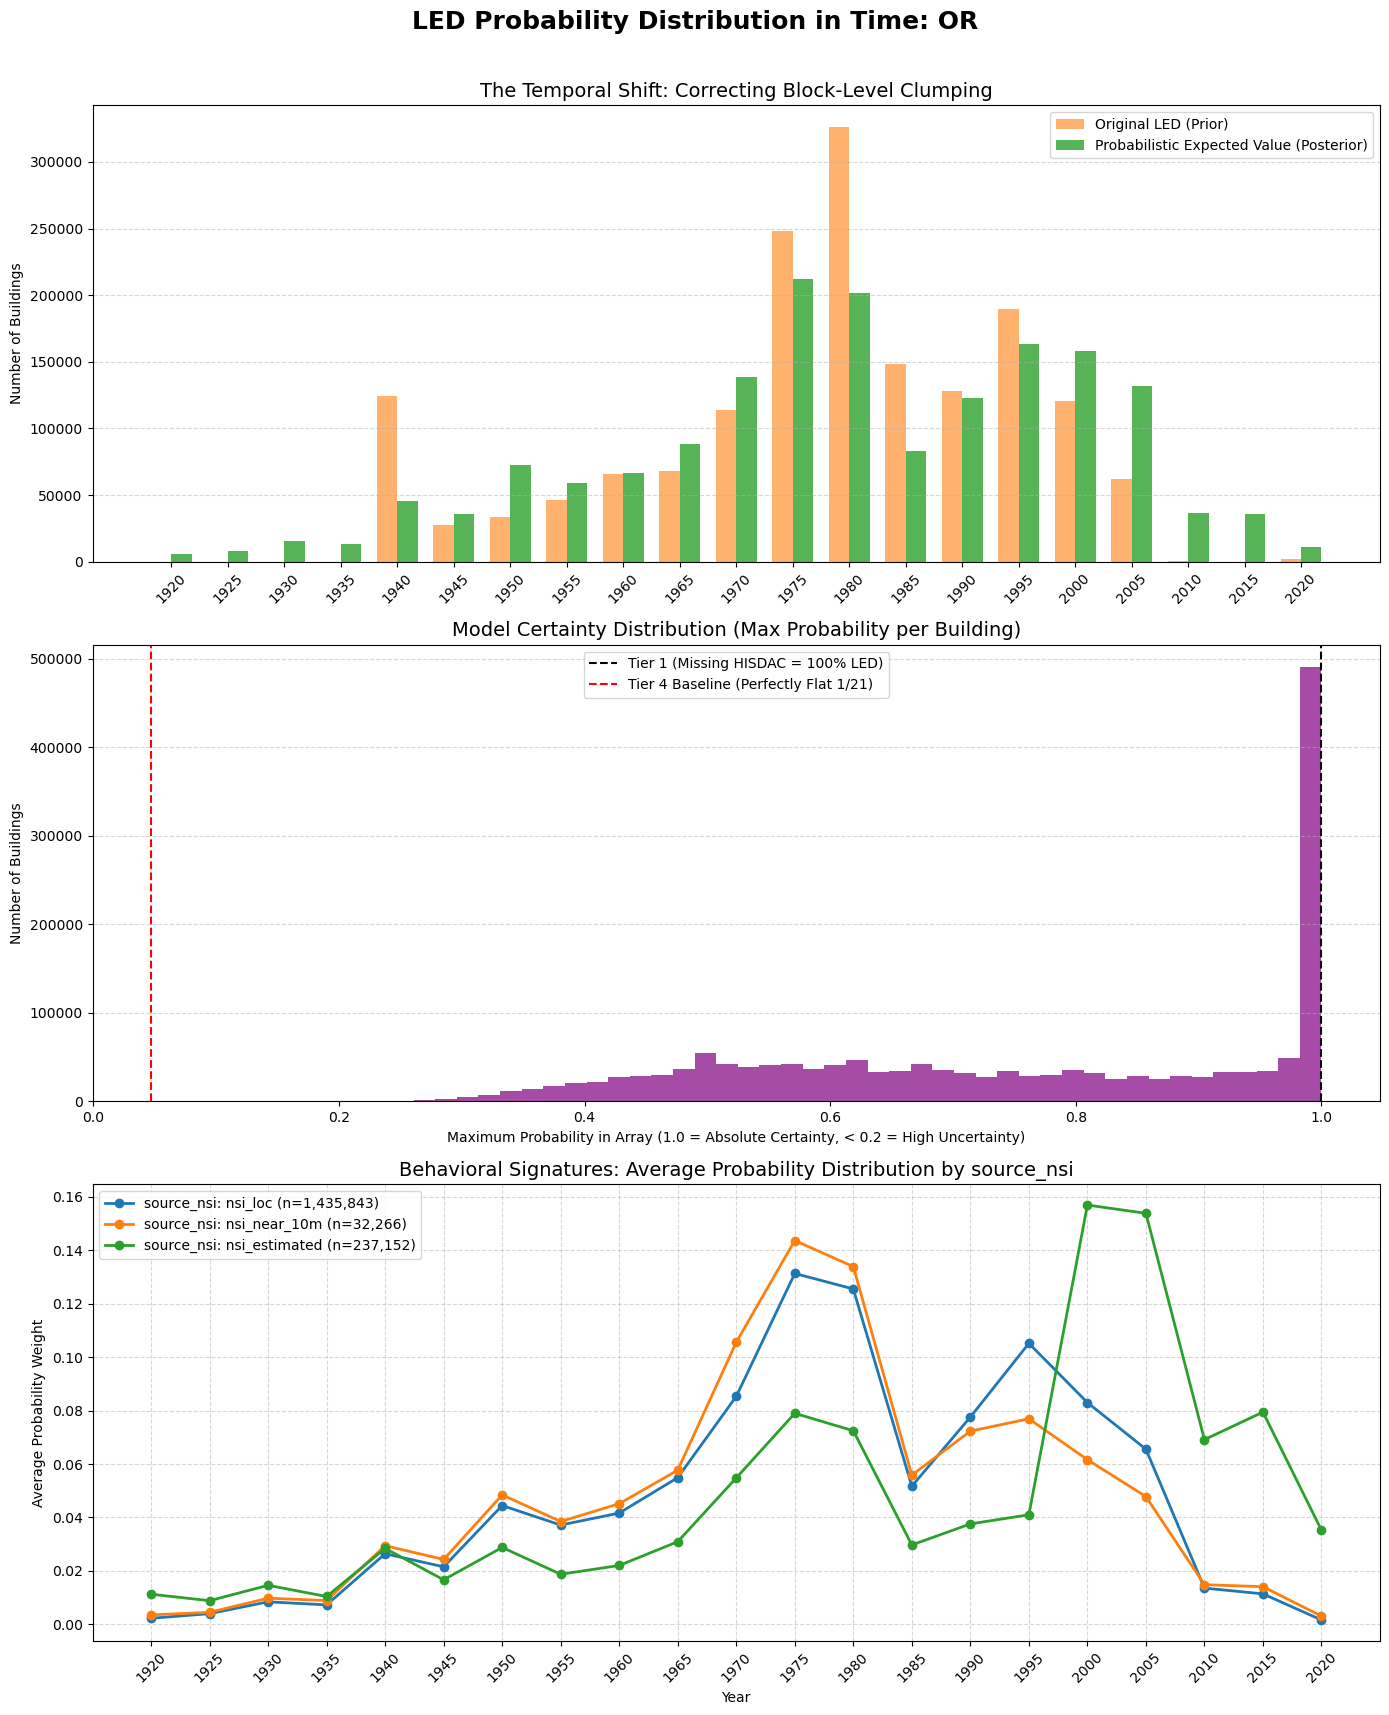

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming led_df is loaded and contains 'prob_distribution', 'semi_decade', and 'source_nsi'
print("\n4) Generating Probability Engine Visualizations...")

# --- Data Prep: Unpack the Probability Arrays ---
# Convert the column of arrays into a massive 2D NumPy matrix for lightning-fast math
# Shape will be (Number of Buildings, 21)
prob_matrix = np.stack(led_df['prob_distribution'].values)
YEARS = np.arange(1920, 2025, 5)

# --- 1. The Temporal Shift (Expected Values) ---
# Sum the probabilities across all buildings for each year
expected_buildings_per_year = np.sum(prob_matrix, axis=0)

# Get the original rigid counts
original_counts = led_df['semi_decade'].value_counts().reindex(YEARS, fill_value=0).values

fig, axs = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle(f"LED Probability Distribution in Time: {state_code}", fontsize=18, fontweight='bold')

# Plot 1
width = 1.8
axs[0].bar(YEARS - width/2, original_counts, width=width, label='Original LED (Prior)', color='#ff7f0e', alpha=0.6)
axs[0].bar(YEARS + width/2, expected_buildings_per_year, width=width, label='Probabilistic Expected Value (Posterior)', color='#2ca02c', alpha=0.8)
axs[0].set_title('The Temporal Shift: Correcting Block-Level Clumping', fontsize=14)
axs[0].set_ylabel('Number of Buildings')
axs[0].set_xticks(YEARS)
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. The Confidence Histogram ---
# Find the highest single probability in every building's array
# A value of 1.0 means absolute certainty; a value of ~0.04 means total uncertainty (1/21)
max_probs = np.max(prob_matrix, axis=1)

axs[1].hist(max_probs, bins=50, color='purple', alpha=0.7)
axs[1].set_title('Model Certainty Distribution (Max Probability per Building)', fontsize=14)
axs[1].set_xlabel('Maximum Probability in Array (1.0 = Absolute Certainty, < 0.2 = High Uncertainty)')
axs[1].set_ylabel('Number of Buildings')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add reference lines for context
axs[1].axvline(1.0, color='black', linestyle='--', label='Tier 1 (Missing HISDAC = 100% LED)')
axs[1].axvline(0.047, color='red', linestyle='--', label='Tier 4 Baseline (Perfectly Flat 1/21)')
axs[1].legend()

# --- 3. source_nsi Signatures (Average Probability Curves) ---
# Group by Overture source_nsi to prove the behavioral logic worked
sources = led_df['source_nsi'].unique()

for src in sources:
    if pd.isna(src): continue
    # Get all arrays for this specific source_nsi
    src_mask = led_df['source_nsi'] == src
    src_matrix = prob_matrix[src_mask]
    
    if len(src_matrix) > 0:
        # Calculate the average curve shape for this source_nsi
        avg_curve = np.mean(src_matrix, axis=0)
        axs[2].plot(YEARS, avg_curve, marker='o', linewidth=2, label=f"source_nsi: {src} (n={len(src_matrix):,})")

axs[2].set_title('Behavioral Signatures: Average Probability Distribution by source_nsi', fontsize=14)
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Average Probability Weight')
axs[2].set_xticks(YEARS)
axs[2].tick_params(axis='x', rotation=45)
axs[2].legend()
axs[2].grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from pathlib import Path
from tqdm import tqdm # Great for progress bars on big datasets

# --- Setup ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"
state_code = "CA"  # Ensure this matches your previous runs
YEARS = np.arange(1920, 2025, 5)

print("1) Loading Datasets...")
master_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_Master_Spatiotemporal_Matrix.parquet")
led_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_LED_Joined_Buildings.parquet")

# Make sure HISDAC_id is the index of master_df for instant lookups
master_idx = master_df.set_index('HISDAC_id')

def generate_probability_array(row):
    """Generates the 21-element array for a single building."""
    hid = row['HISDAC_id']
    
    # If the building is in a location where HISDAC completely failed to create a pixel
    if hid not in master_idx.index:
        prob_array = np.zeros(21)
        year_idx = np.where(YEARS == row['semi_decade'])[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    pixel = master_idx.loc[hid]
    
    # Extract variables
    led_year = row['semi_decade']
    source_nsi = row.get('source_nsi', 'unknown')
    stories = row.get('num_story', 1)
    if pd.isna(stories): stories = 1
    
    # Extract arrays
    hisdac_bupl = np.array([pixel[f'D_BUPL{y}'] for y in YEARS])
    led_counts = np.array([pixel[f'LED_{y}'] for y in YEARS])
    density = pixel['DENSITY']
    fbuy = pixel['FBUY']
    
    prob_array = np.zeros(21)
    
    # TIER 1: HISDAC Void
    if pd.isna(fbuy) or np.sum(hisdac_bupl) == 0:
        year_idx = np.where(YEARS == led_year)[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    # TIER 4: Urban Blender (Density > 3.0)
    if density > 3.0:
        if stories > 3:
            # The Culprit
            hisdac_bupr = np.array([pixel[f'D_BUPR{y}'] for y in YEARS])
            if np.sum(hisdac_bupr) > 0:
                return hisdac_bupr / np.sum(hisdac_bupr)
            return np.ones(21) / 21
        else:
            # The Bystander
            base_dist = hisdac_bupl / np.sum(hisdac_bupl)
            gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=10)
            prob_array = base_dist * gaussian_weights
            return prob_array / np.sum(prob_array) if np.sum(prob_array) > 0 else base_dist

    # TIER 3: Deficit Allocation (nsi_estimated)
    if source_nsi == 'nsi_estimated':
        recent_idx = slice(16, 21) # 2000-2020
        deficits = np.maximum(0, hisdac_bupl[recent_idx] - led_counts[recent_idx])
        if np.sum(deficits) > 0:
            prob_array[recent_idx] = deficits / np.sum(deficits)
            return prob_array

    # TIER 2: Anchored Ground Truth (nsi_loc or standard fallback)
    base_dist = hisdac_bupl / np.sum(hisdac_bupl)
    gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=5)
    prob_array = base_dist * gaussian_weights
    
    if np.sum(prob_array) > 0:
        return prob_array / np.sum(prob_array)
    return np.ones(21) / 21


print("2) Generating Probabilities...")
# Using tqdm to show progress on massive datasets
tqdm.pandas(desc="Calculating Probability Arrays")
led_df['prob_distribution'] = led_df.progress_apply(generate_probability_array, axis=1)

print("\n3) Saving Monte Carlo Engine...")
out_path = TESTING_SET_PATH / f"{state_code}_LED_Monte_Carlo_Engine.parquet"
led_df.to_parquet(out_path, index=False)
print(f"SUCCESS! Engine saved to: {out_path}")

1) Loading Datasets...
2) Generating Probabilities...


Calculating Probability Arrays: 100%|██████████| 10400034/10400034 [58:47<00:00, 2947.90it/s] 



3) Saving Monte Carlo Engine...
SUCCESS! Engine saved to: /Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data/Testing_Set/CA_LED_Monte_Carlo_Engine.parquet



4) Generating Probability Engine Visualizations...


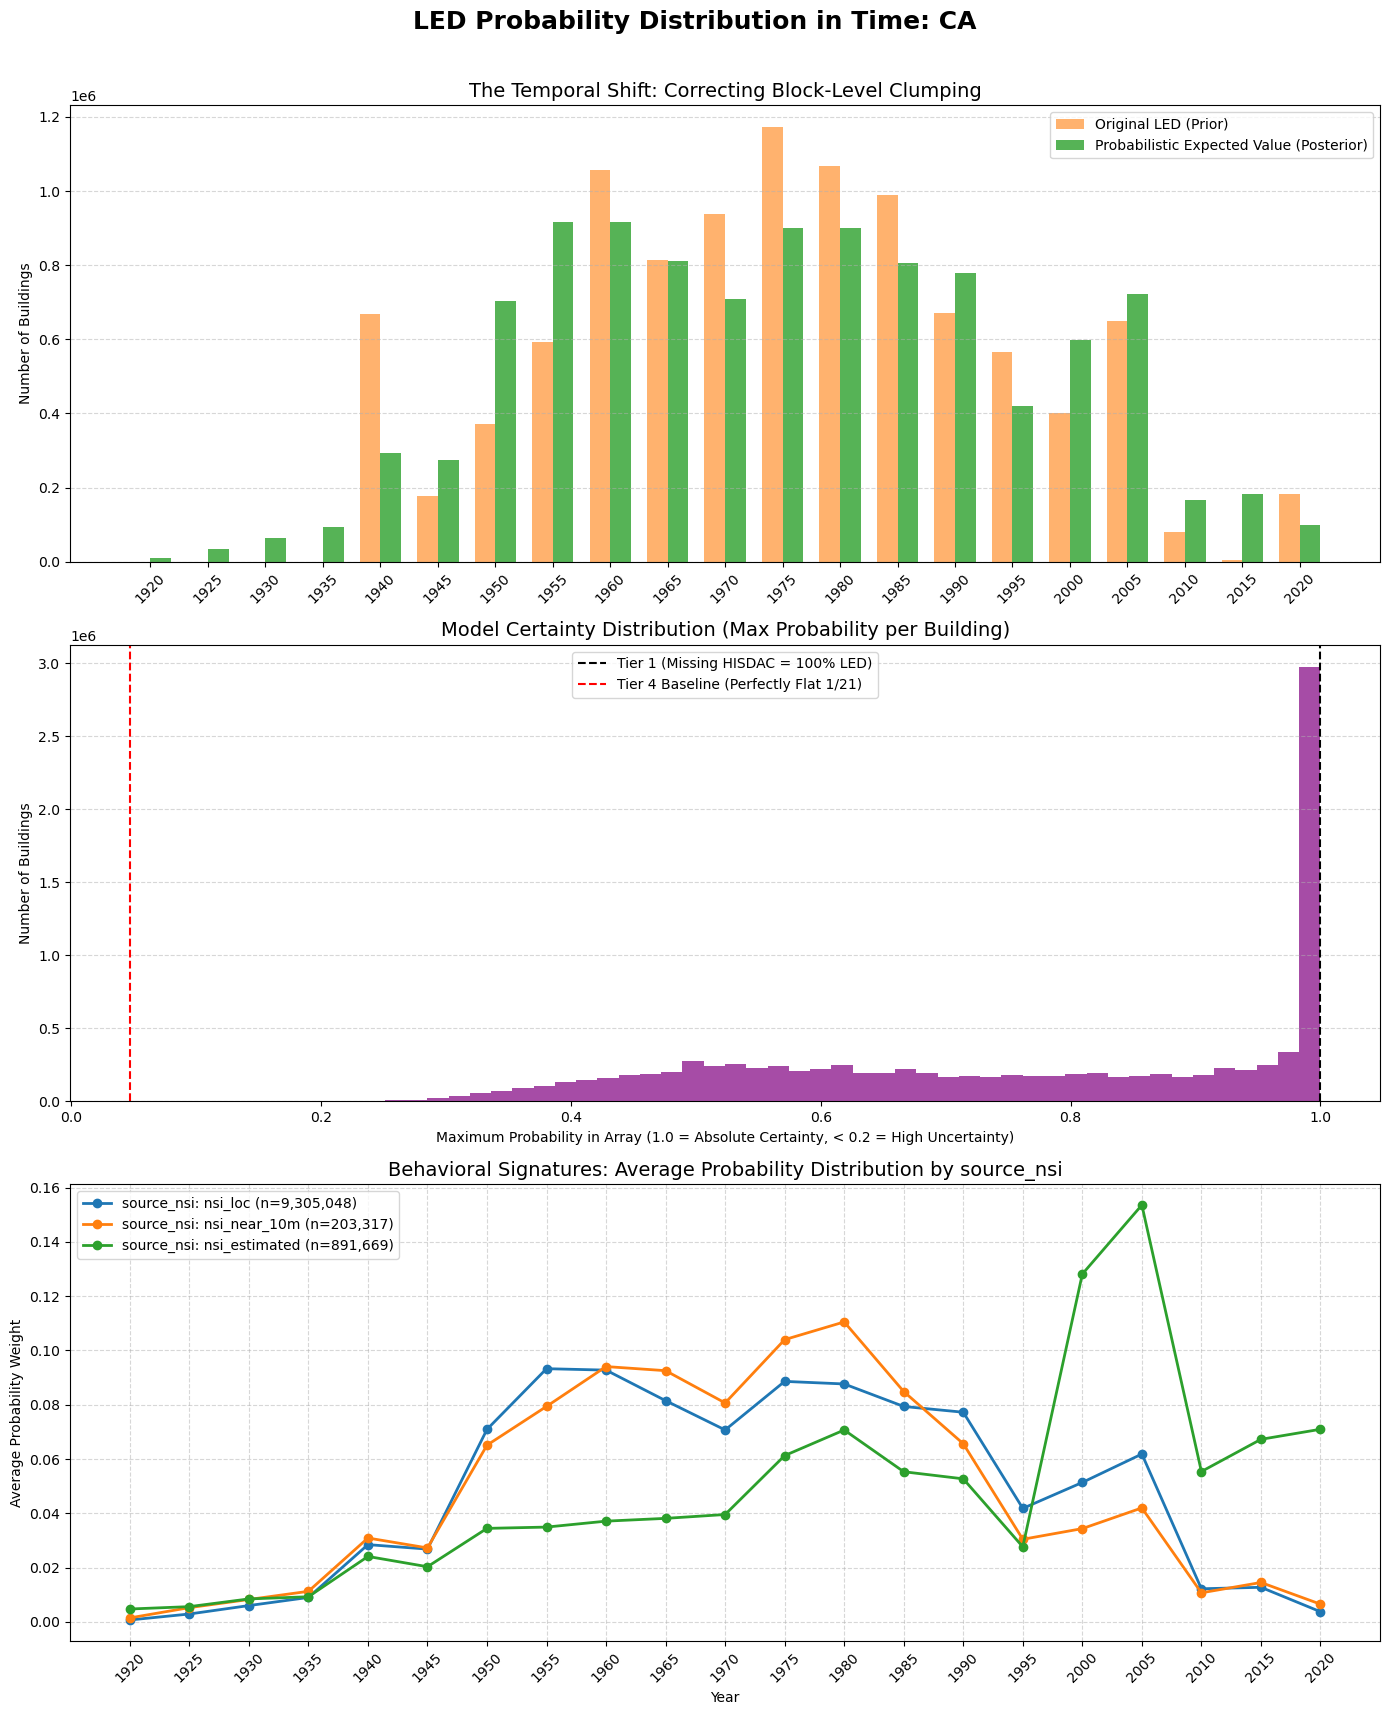

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming led_df is loaded and contains 'prob_distribution', 'semi_decade', and 'source_nsi'
print("\n4) Generating Probability Engine Visualizations...")

# --- Data Prep: Unpack the Probability Arrays ---
# Convert the column of arrays into a massive 2D NumPy matrix for lightning-fast math
# Shape will be (Number of Buildings, 21)
prob_matrix = np.stack(led_df['prob_distribution'].values)
YEARS = np.arange(1920, 2025, 5)

# --- 1. The Temporal Shift (Expected Values) ---
# Sum the probabilities across all buildings for each year
expected_buildings_per_year = np.sum(prob_matrix, axis=0)

# Get the original rigid counts
original_counts = led_df['semi_decade'].value_counts().reindex(YEARS, fill_value=0).values

fig, axs = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle(f"LED Probability Distribution in Time: {state_code}", fontsize=18, fontweight='bold')

# Plot 1
width = 1.8
axs[0].bar(YEARS - width/2, original_counts, width=width, label='Original LED (Prior)', color='#ff7f0e', alpha=0.6)
axs[0].bar(YEARS + width/2, expected_buildings_per_year, width=width, label='Probabilistic Expected Value (Posterior)', color='#2ca02c', alpha=0.8)
axs[0].set_title('The Temporal Shift: Correcting Block-Level Clumping', fontsize=14)
axs[0].set_ylabel('Number of Buildings')
axs[0].set_xticks(YEARS)
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. The Confidence Histogram ---
# Find the highest single probability in every building's array
# A value of 1.0 means absolute certainty; a value of ~0.04 means total uncertainty (1/21)
max_probs = np.max(prob_matrix, axis=1)

axs[1].hist(max_probs, bins=50, color='purple', alpha=0.7)
axs[1].set_title('Model Certainty Distribution (Max Probability per Building)', fontsize=14)
axs[1].set_xlabel('Maximum Probability in Array (1.0 = Absolute Certainty, < 0.2 = High Uncertainty)')
axs[1].set_ylabel('Number of Buildings')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add reference lines for context
axs[1].axvline(1.0, color='black', linestyle='--', label='Tier 1 (Missing HISDAC = 100% LED)')
axs[1].axvline(0.047, color='red', linestyle='--', label='Tier 4 Baseline (Perfectly Flat 1/21)')
axs[1].legend()

# --- 3. source_nsi Signatures (Average Probability Curves) ---
# Group by Overture source_nsi to prove the behavioral logic worked
sources = led_df['source_nsi'].unique()

for src in sources:
    if pd.isna(src): continue
    # Get all arrays for this specific source_nsi
    src_mask = led_df['source_nsi'] == src
    src_matrix = prob_matrix[src_mask]
    
    if len(src_matrix) > 0:
        # Calculate the average curve shape for this source_nsi
        avg_curve = np.mean(src_matrix, axis=0)
        axs[2].plot(YEARS, avg_curve, marker='o', linewidth=2, label=f"source_nsi: {src} (n={len(src_matrix):,})")

axs[2].set_title('Behavioral Signatures: Average Probability Distribution by source_nsi', fontsize=14)
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Average Probability Weight')
axs[2].set_xticks(YEARS)
axs[2].tick_params(axis='x', rotation=45)
axs[2].legend()
axs[2].grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from pathlib import Path
from tqdm import tqdm # Great for progress bars on big datasets

# --- Setup ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"
state_code = "NC"  # Ensure this matches your previous runs
YEARS = np.arange(1920, 2025, 5)

print("1) Loading Datasets...")
master_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_Master_Spatiotemporal_Matrix.parquet")
led_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_LED_Joined_Buildings.parquet")

# Make sure HISDAC_id is the index of master_df for instant lookups
master_idx = master_df.set_index('HISDAC_id')

def generate_probability_array(row):
    """Generates the 21-element array for a single building."""
    hid = row['HISDAC_id']
    
    # If the building is in a location where HISDAC completely failed to create a pixel
    if hid not in master_idx.index:
        prob_array = np.zeros(21)
        year_idx = np.where(YEARS == row['semi_decade'])[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    pixel = master_idx.loc[hid]
    
    # Extract variables
    led_year = row['semi_decade']
    source_nsi = row.get('source_nsi', 'unknown')
    stories = row.get('num_story', 1)
    if pd.isna(stories): stories = 1
    
    # Extract arrays
    hisdac_bupl = np.array([pixel[f'D_BUPL{y}'] for y in YEARS])
    led_counts = np.array([pixel[f'LED_{y}'] for y in YEARS])
    density = pixel['DENSITY']
    fbuy = pixel['FBUY']
    
    prob_array = np.zeros(21)
    
    # TIER 1: HISDAC Void
    if pd.isna(fbuy) or np.sum(hisdac_bupl) == 0:
        year_idx = np.where(YEARS == led_year)[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    # TIER 4: Urban Blender (Density > 3.0)
    if density > 3.0:
        if stories > 3:
            # The Culprit
            hisdac_bupr = np.array([pixel[f'D_BUPR{y}'] for y in YEARS])
            if np.sum(hisdac_bupr) > 0:
                return hisdac_bupr / np.sum(hisdac_bupr)
            return np.ones(21) / 21
        else:
            # The Bystander
            base_dist = hisdac_bupl / np.sum(hisdac_bupl)
            gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=10)
            prob_array = base_dist * gaussian_weights
            return prob_array / np.sum(prob_array) if np.sum(prob_array) > 0 else base_dist

    # TIER 3: Deficit Allocation (nsi_estimated)
    if source_nsi == 'nsi_estimated':
        recent_idx = slice(16, 21) # 2000-2020
        deficits = np.maximum(0, hisdac_bupl[recent_idx] - led_counts[recent_idx])
        if np.sum(deficits) > 0:
            prob_array[recent_idx] = deficits / np.sum(deficits)
            return prob_array

    # TIER 2: Anchored Ground Truth (nsi_loc or standard fallback)
    base_dist = hisdac_bupl / np.sum(hisdac_bupl)
    gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=5)
    prob_array = base_dist * gaussian_weights
    
    if np.sum(prob_array) > 0:
        return prob_array / np.sum(prob_array)
    return np.ones(21) / 21


print("2) Generating Probabilities...")
# Using tqdm to show progress on massive datasets
tqdm.pandas(desc="Calculating Probability Arrays")
led_df['prob_distribution'] = led_df.progress_apply(generate_probability_array, axis=1)

print("\n3) Saving Monte Carlo Engine...")
out_path = TESTING_SET_PATH / f"{state_code}_LED_Monte_Carlo_Engine.parquet"
led_df.to_parquet(out_path, index=False)
print(f"SUCCESS! Engine saved to: {out_path}")

1) Loading Datasets...
2) Generating Probabilities...


Calculating Probability Arrays: 100%|██████████| 4588636/4588636 [25:17<00:00, 3023.42it/s]



3) Saving Monte Carlo Engine...
SUCCESS! Engine saved to: /Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data/Testing_Set/NC_LED_Monte_Carlo_Engine.parquet



4) Generating Probability Engine Visualizations...


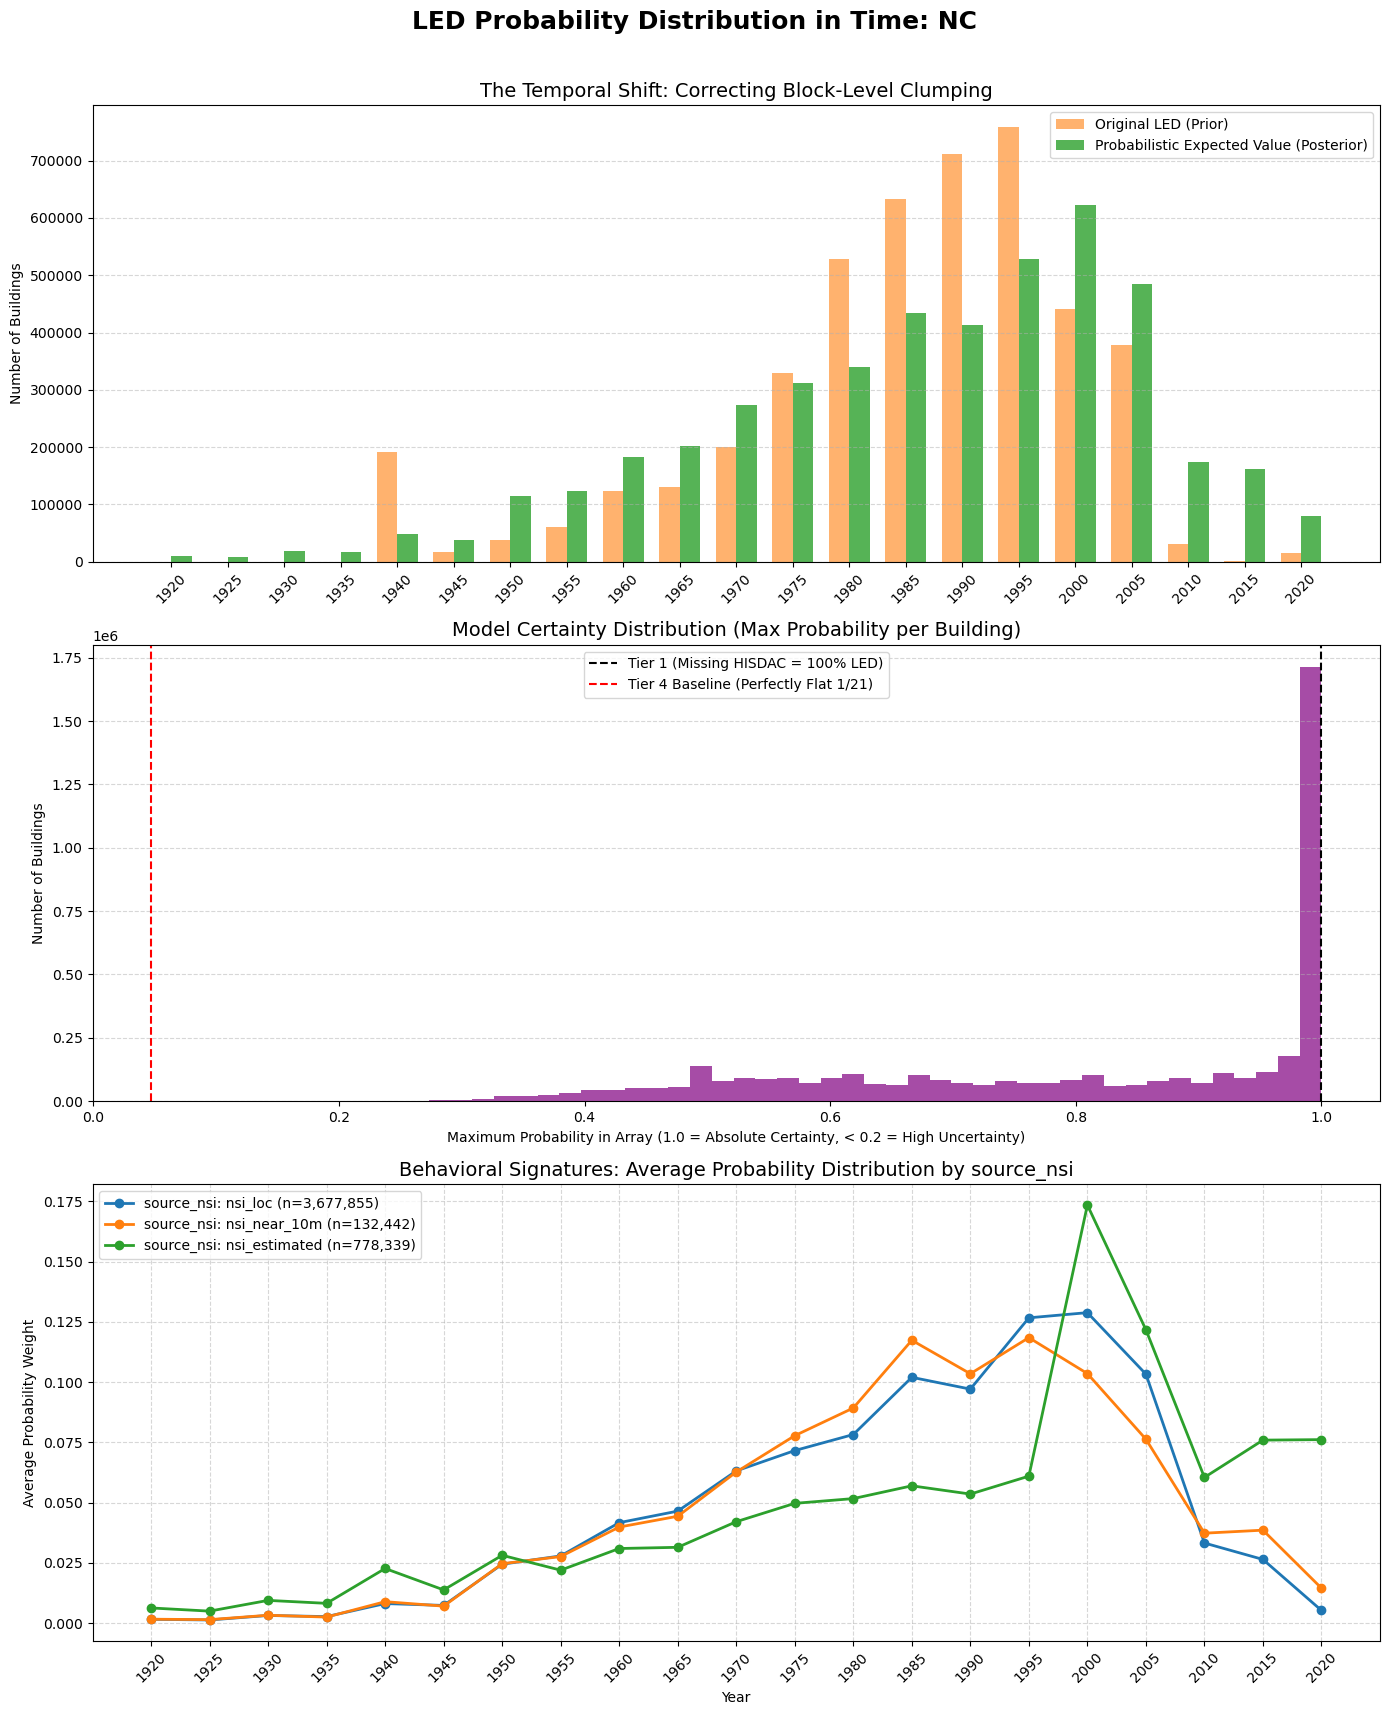

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming led_df is loaded and contains 'prob_distribution', 'semi_decade', and 'source_nsi'
print("\n4) Generating Probability Engine Visualizations...")

# --- Data Prep: Unpack the Probability Arrays ---
# Convert the column of arrays into a massive 2D NumPy matrix for lightning-fast math
# Shape will be (Number of Buildings, 21)
prob_matrix = np.stack(led_df['prob_distribution'].values)
YEARS = np.arange(1920, 2025, 5)

# --- 1. The Temporal Shift (Expected Values) ---
# Sum the probabilities across all buildings for each year
expected_buildings_per_year = np.sum(prob_matrix, axis=0)

# Get the original rigid counts
original_counts = led_df['semi_decade'].value_counts().reindex(YEARS, fill_value=0).values

fig, axs = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle(f"LED Probability Distribution in Time: {state_code}", fontsize=18, fontweight='bold')

# Plot 1
width = 1.8
axs[0].bar(YEARS - width/2, original_counts, width=width, label='Original LED (Prior)', color='#ff7f0e', alpha=0.6)
axs[0].bar(YEARS + width/2, expected_buildings_per_year, width=width, label='Probabilistic Expected Value (Posterior)', color='#2ca02c', alpha=0.8)
axs[0].set_title('The Temporal Shift: Correcting Block-Level Clumping', fontsize=14)
axs[0].set_ylabel('Number of Buildings')
axs[0].set_xticks(YEARS)
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. The Confidence Histogram ---
# Find the highest single probability in every building's array
# A value of 1.0 means absolute certainty; a value of ~0.04 means total uncertainty (1/21)
max_probs = np.max(prob_matrix, axis=1)

axs[1].hist(max_probs, bins=50, color='purple', alpha=0.7)
axs[1].set_title('Model Certainty Distribution (Max Probability per Building)', fontsize=14)
axs[1].set_xlabel('Maximum Probability in Array (1.0 = Absolute Certainty, < 0.2 = High Uncertainty)')
axs[1].set_ylabel('Number of Buildings')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add reference lines for context
axs[1].axvline(1.0, color='black', linestyle='--', label='Tier 1 (Missing HISDAC = 100% LED)')
axs[1].axvline(0.047, color='red', linestyle='--', label='Tier 4 Baseline (Perfectly Flat 1/21)')
axs[1].legend()

# --- 3. source_nsi Signatures (Average Probability Curves) ---
# Group by Overture source_nsi to prove the behavioral logic worked
sources = led_df['source_nsi'].unique()

for src in sources:
    if pd.isna(src): continue
    # Get all arrays for this specific source_nsi
    src_mask = led_df['source_nsi'] == src
    src_matrix = prob_matrix[src_mask]
    
    if len(src_matrix) > 0:
        # Calculate the average curve shape for this source_nsi
        avg_curve = np.mean(src_matrix, axis=0)
        axs[2].plot(YEARS, avg_curve, marker='o', linewidth=2, label=f"source_nsi: {src} (n={len(src_matrix):,})")

axs[2].set_title('Behavioral Signatures: Average Probability Distribution by source_nsi', fontsize=14)
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Average Probability Weight')
axs[2].set_xticks(YEARS)
axs[2].tick_params(axis='x', rotation=45)
axs[2].legend()
axs[2].grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from pathlib import Path
from tqdm import tqdm # Great for progress bars on big datasets

# --- Setup ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"
state_code = "WV"  # Ensure this matches your previous runs
YEARS = np.arange(1920, 2025, 5)

print("1) Loading Datasets...")
master_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_Master_Spatiotemporal_Matrix.parquet")
led_df = pd.read_parquet(TESTING_SET_PATH / f"{state_code}_LED_Joined_Buildings.parquet")

# Make sure HISDAC_id is the index of master_df for instant lookups
master_idx = master_df.set_index('HISDAC_id')

def generate_probability_array(row):
    """Generates the 21-element array for a single building."""
    hid = row['HISDAC_id']
    
    # If the building is in a location where HISDAC completely failed to create a pixel
    if hid not in master_idx.index:
        prob_array = np.zeros(21)
        year_idx = np.where(YEARS == row['semi_decade'])[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    pixel = master_idx.loc[hid]
    
    # Extract variables
    led_year = row['semi_decade']
    source_nsi = row.get('source_nsi', 'unknown')
    stories = row.get('num_story', 1)
    if pd.isna(stories): stories = 1
    
    # Extract arrays
    hisdac_bupl = np.array([pixel[f'D_BUPL{y}'] for y in YEARS])
    led_counts = np.array([pixel[f'LED_{y}'] for y in YEARS])
    density = pixel['DENSITY']
    fbuy = pixel['FBUY']
    
    prob_array = np.zeros(21)
    
    # TIER 1: HISDAC Void
    if pd.isna(fbuy) or np.sum(hisdac_bupl) == 0:
        year_idx = np.where(YEARS == led_year)[0][0]
        prob_array[year_idx] = 1.0
        return prob_array

    # TIER 4: Urban Blender (Density > 3.0)
    if density > 3.0:
        if stories > 3:
            # The Culprit
            hisdac_bupr = np.array([pixel[f'D_BUPR{y}'] for y in YEARS])
            if np.sum(hisdac_bupr) > 0:
                return hisdac_bupr / np.sum(hisdac_bupr)
            return np.ones(21) / 21
        else:
            # The Bystander
            base_dist = hisdac_bupl / np.sum(hisdac_bupl)
            gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=10)
            prob_array = base_dist * gaussian_weights
            return prob_array / np.sum(prob_array) if np.sum(prob_array) > 0 else base_dist

    # TIER 3: Deficit Allocation (nsi_estimated)
    if source_nsi == 'nsi_estimated':
        recent_idx = slice(16, 21) # 2000-2020
        deficits = np.maximum(0, hisdac_bupl[recent_idx] - led_counts[recent_idx])
        if np.sum(deficits) > 0:
            prob_array[recent_idx] = deficits / np.sum(deficits)
            return prob_array

    # TIER 2: Anchored Ground Truth (nsi_loc or standard fallback)
    base_dist = hisdac_bupl / np.sum(hisdac_bupl)
    gaussian_weights = norm.pdf(YEARS, loc=led_year, scale=5)
    prob_array = base_dist * gaussian_weights
    
    if np.sum(prob_array) > 0:
        return prob_array / np.sum(prob_array)
    return np.ones(21) / 21


print("2) Generating Probabilities...")
# Using tqdm to show progress on massive datasets
tqdm.pandas(desc="Calculating Probability Arrays")
led_df['prob_distribution'] = led_df.progress_apply(generate_probability_array, axis=1)

print("\n3) Saving Monte Carlo Engine...")
out_path = TESTING_SET_PATH / f"{state_code}_LED_Monte_Carlo_Engine.parquet"
led_df.to_parquet(out_path, index=False)
print(f"SUCCESS! Engine saved to: {out_path}")

1) Loading Datasets...
2) Generating Probabilities...


Calculating Probability Arrays: 100%|██████████| 786450/786450 [04:22<00:00, 2994.49it/s]



3) Saving Monte Carlo Engine...
SUCCESS! Engine saved to: /Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data/Testing_Set/WV_LED_Monte_Carlo_Engine.parquet



4) Generating Probability Engine Visualizations...


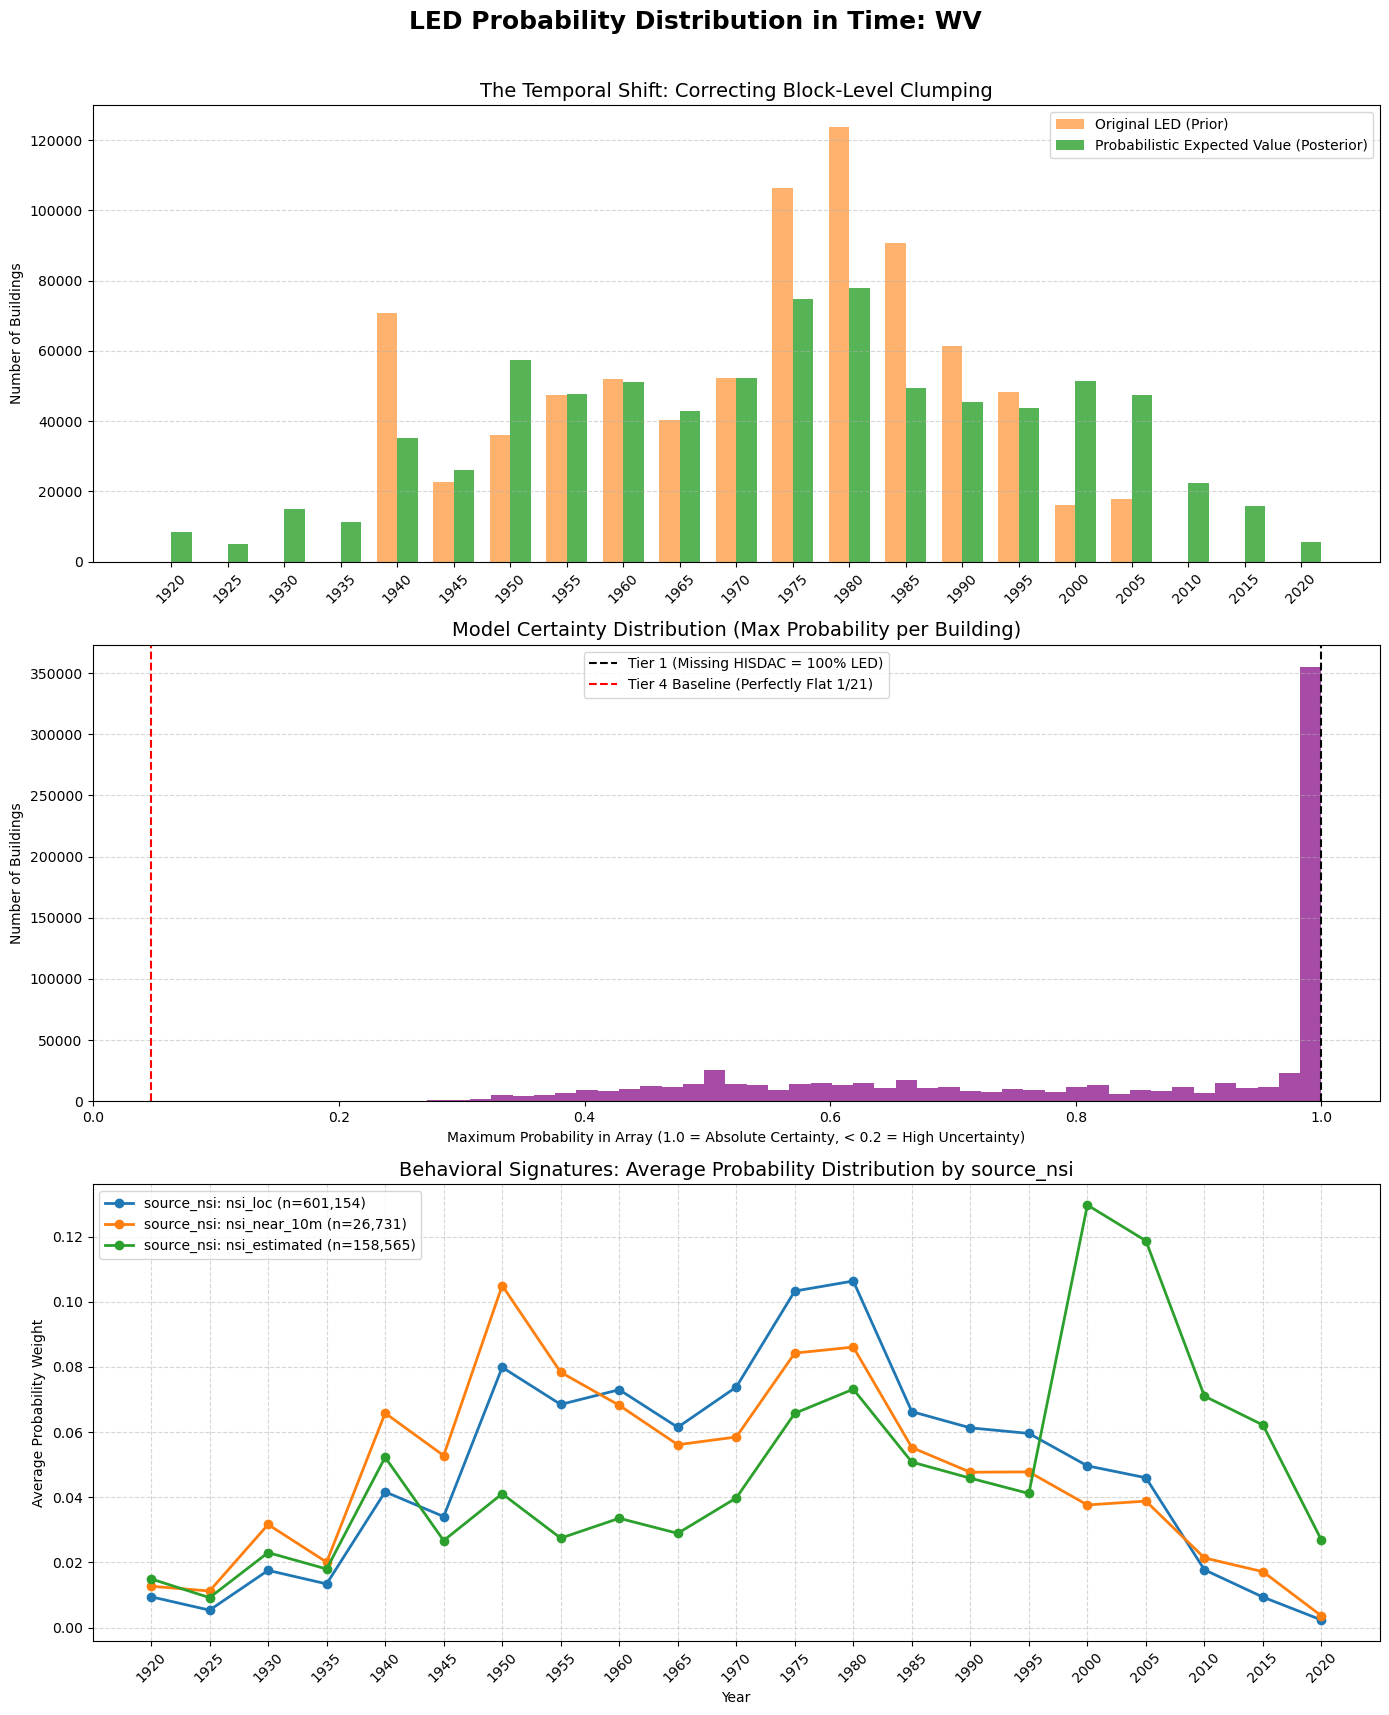

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming led_df is loaded and contains 'prob_distribution', 'semi_decade', and 'source_nsi'
print("\n4) Generating Probability Engine Visualizations...")

# --- Data Prep: Unpack the Probability Arrays ---
# Convert the column of arrays into a massive 2D NumPy matrix for lightning-fast math
# Shape will be (Number of Buildings, 21)
prob_matrix = np.stack(led_df['prob_distribution'].values)
YEARS = np.arange(1920, 2025, 5)

# --- 1. The Temporal Shift (Expected Values) ---
# Sum the probabilities across all buildings for each year
expected_buildings_per_year = np.sum(prob_matrix, axis=0)

# Get the original rigid counts
original_counts = led_df['semi_decade'].value_counts().reindex(YEARS, fill_value=0).values

fig, axs = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle(f"LED Probability Distribution in Time: {state_code}", fontsize=18, fontweight='bold')

# Plot 1
width = 1.8
axs[0].bar(YEARS - width/2, original_counts, width=width, label='Original LED (Prior)', color='#ff7f0e', alpha=0.6)
axs[0].bar(YEARS + width/2, expected_buildings_per_year, width=width, label='Probabilistic Expected Value (Posterior)', color='#2ca02c', alpha=0.8)
axs[0].set_title('The Temporal Shift: Correcting Block-Level Clumping', fontsize=14)
axs[0].set_ylabel('Number of Buildings')
axs[0].set_xticks(YEARS)
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. The Confidence Histogram ---
# Find the highest single probability in every building's array
# A value of 1.0 means absolute certainty; a value of ~0.04 means total uncertainty (1/21)
max_probs = np.max(prob_matrix, axis=1)

axs[1].hist(max_probs, bins=50, color='purple', alpha=0.7)
axs[1].set_title('Model Certainty Distribution (Max Probability per Building)', fontsize=14)
axs[1].set_xlabel('Maximum Probability in Array (1.0 = Absolute Certainty, < 0.2 = High Uncertainty)')
axs[1].set_ylabel('Number of Buildings')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add reference lines for context
axs[1].axvline(1.0, color='black', linestyle='--', label='Tier 1 (Missing HISDAC = 100% LED)')
axs[1].axvline(0.047, color='red', linestyle='--', label='Tier 4 Baseline (Perfectly Flat 1/21)')
axs[1].legend()

# --- 3. source_nsi Signatures (Average Probability Curves) ---
# Group by Overture source_nsi to prove the behavioral logic worked
sources = led_df['source_nsi'].unique()

for src in sources:
    if pd.isna(src): continue
    # Get all arrays for this specific source_nsi
    src_mask = led_df['source_nsi'] == src
    src_matrix = prob_matrix[src_mask]
    
    if len(src_matrix) > 0:
        # Calculate the average curve shape for this source_nsi
        avg_curve = np.mean(src_matrix, axis=0)
        axs[2].plot(YEARS, avg_curve, marker='o', linewidth=2, label=f"source_nsi: {src} (n={len(src_matrix):,})")

axs[2].set_title('Behavioral Signatures: Average Probability Distribution by source_nsi', fontsize=14)
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Average Probability Weight')
axs[2].set_xticks(YEARS)
axs[2].tick_params(axis='x', rotation=45)
axs[2].legend()
axs[2].grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()